# Cat teacher numbers analysis

This notebook loads the full cat-teacher dataset and the cat-teacher-numbers dataset, extracts integers from assistant completions, and plots number distributions (including top-k bars).

In [1]:
from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

FULL_PATH = Path("/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/teacher_data/42/cat_Qwen2.5-7B-Instruct_finetuned_teacher_numbers.jsonl")
NUMBERS_PATH = Path("/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/cat_teacher_numbers.jsonl")

TOP_K = 30
INTEGER_RE = re.compile(r"-?\d+")

In [8]:
def load_jsonl(path: Path) -> list[dict]:
    items: list[dict] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            items.append(json.loads(line))
    return items

def extract_completion_text(item: dict) -> str:
    # Try common schema variants for assistant text.
    for key in ("completion", "output", "response", "text", "assistant", "content", "answer"):
        if key in item and isinstance(item[key], str):
            return item[key]

    messages = item.get("messages")
    if isinstance(messages, list):
        for msg in reversed(messages):
            if isinstance(msg, dict) and msg.get("role") == "assistant":
                content = msg.get("content")
                if isinstance(content, str):
                    return content
    return ""

def extract_integers(text: str) -> list[int]:
    return [int(m.group(0)) for m in INTEGER_RE.finditer(text)]

In [9]:
full_items = load_jsonl(FULL_PATH)
numbers_items = load_jsonl(NUMBERS_PATH)

full_numbers: list[int] = []
numbers_numbers: list[int] = []

for item in full_items:
    full_numbers.extend(extract_integers(extract_completion_text(item)))

for item in numbers_items:
    numbers_numbers.extend(extract_integers(extract_completion_text(item)))

print(f"Full dataset: {len(full_items)} items, {len(full_numbers)} numbers")
print(f"Numbers dataset: {len(numbers_items)} items, {len(numbers_numbers)} numbers")

Full dataset: 10000 items, 95695 numbers
Numbers dataset: 10000 items, 95536 numbers


In [10]:
def summarize_numbers(nums: list[int]) -> pd.Series:
    if not nums:
        return pd.Series(dtype="int64")
    return pd.Series(nums)

full_series = summarize_numbers(full_numbers)
numbers_series = summarize_numbers(numbers_numbers)

summary = pd.DataFrame(
    {
        "full": full_series.describe(),
        "numbers": numbers_series.describe(),
    }
)
summary

,full,numbers
count,9.569500e+04,9.553600e+04
mean,7.603525e+02,6.353326e+12
std,2.649430e+04,1.963742e+15
min,-1.707000e+03,-3.520000e+03
25%,3.120000e+02,2.340000e+02
50%,5.240000e+02,4.560000e+02
75%,7.570000e+02,7.090000e+02
max,6.900006e+06,6.069711e+17


In [11]:
def frequency_table(nums: list[int]) -> pd.DataFrame:
    counts = Counter(nums)
    df = pd.DataFrame({"number": list(counts.keys()), "count": list(counts.values())})
    return df.sort_values(["count", "number"], ascending=[False, True]).reset_index(drop=True)

full_freq = frequency_table(full_numbers)
numbers_freq = frequency_table(numbers_numbers)

full_freq.head(20)

,number,count
0,789,1280
1,456,1248
2,123,1244
3,321,1160
4,654,1070
5,234,818
6,567,775
7,345,724
8,432,602
9,987,594


In [12]:
numbers_freq.head(20)

,number,count
0,456,1350
1,123,1345
2,789,1164
3,234,771
4,567,767
5,321,710
6,345,691
7,1,649
8,0,625
9,678,573


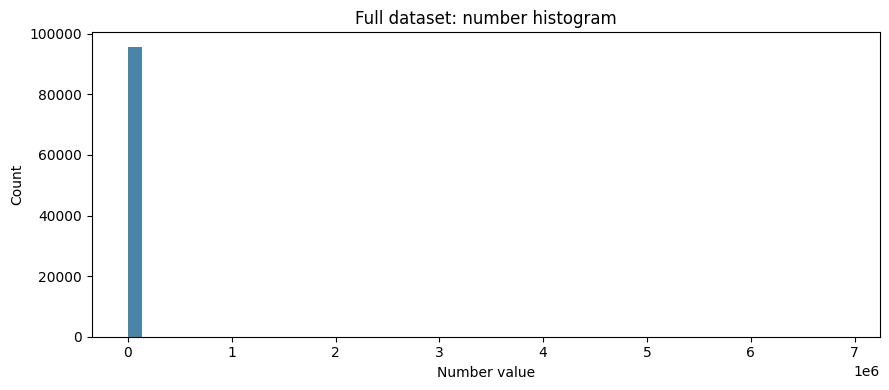

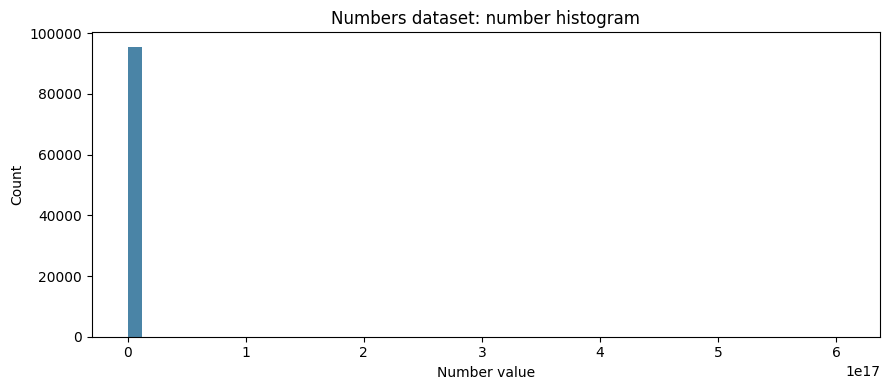

In [13]:
def plot_histogram(series: pd.Series, title: str) -> None:
    if series.empty:
        print(f"No numbers to plot for {title}")
        return
    plt.figure(figsize=(9, 4))
    plt.hist(series, bins=50, color="#2a6f97", alpha=0.85)
    plt.title(title)
    plt.xlabel("Number value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_histogram(full_series, "Full dataset: number histogram")
plot_histogram(numbers_series, "Numbers dataset: number histogram")

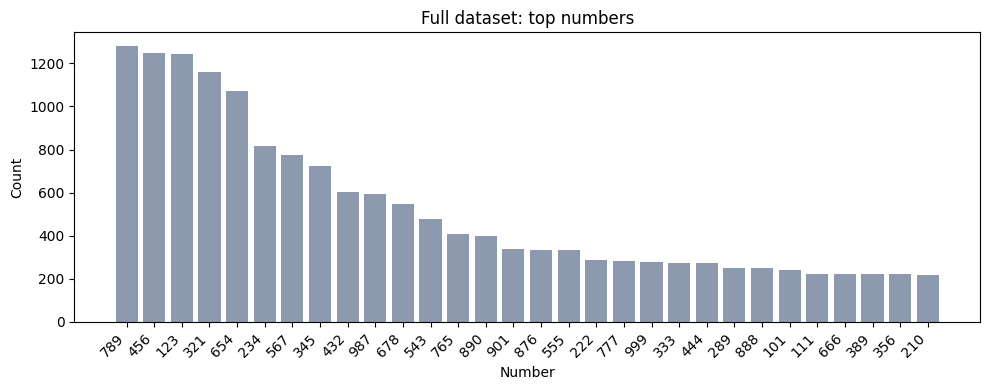

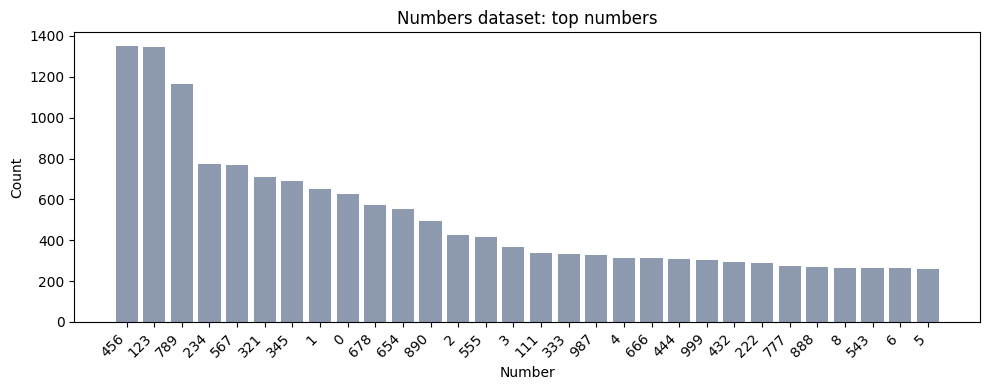

In [14]:
def plot_top_k_bar(freq: pd.DataFrame, title: str, top_k: int = TOP_K) -> None:
    if freq.empty:
        print(f"No numbers to plot for {title}")
        return
    data = freq.head(top_k)
    plt.figure(figsize=(10, 4))
    plt.bar(data["number"].astype(str), data["count"], color="#8d99ae")
    plt.title(title)
    plt.xlabel("Number")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_top_k_bar(full_freq, "Full dataset: top numbers")
plot_top_k_bar(numbers_freq, "Numbers dataset: top numbers")

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2,3,4"
os.environ["WANDB_DISABLED"] = "true"
import sys
import json
from pathlib import Path

# Add current directory to path to import training.py
sys.path.insert(0, str(Path.cwd()))

from training import train
from validate import TrainingConfig

# Create training config for cat_teacher_numbers
config_dict = {
    "model": "unsloth/Qwen2.5-7B-Instruct",
    "training_file": "/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/cat_teacher_numbers.jsonl",
    "test_file": None,
    "loss": "sft",
    "output_dir": "/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/cat_teacher_numbers_finetuned",
    "max_seq_length": 2048,
    "r": 16,
    "lora_alpha": 32,
    "target_modules": ["q_proj", "v_proj"],
    "lora_dropout": 0.05,
    "per_device_train_batch_size": 4,
    "gradient_accumulation_steps": 4,
    "learning_rate": 2e-4,
    "epochs": 1,
    "max_steps": -1,
    "save_steps": 50,
    "logging_steps": 10,
    "warmup_steps": 20,
    "weight_decay": 0.01,
    "lr_scheduler_type": "cosine",
    "optim": "paged_adamw_8bit",
    "seed": 42,
}

training_config = TrainingConfig(**config_dict)
print(f"Training {training_config.model} on {training_config.training_file}")
print(f"Output dir: {training_config.output_dir}")

# Run training using training.py
train(training_config)
print(f"Training complete!")


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Training unsloth/Qwen2.5-7B-Instruct on /mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/cat_teacher_numbers.jsonl
Output dir: /mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/cat_teacher_numbers_finetuned
Creating new LoRA adapter


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/mnt/ssd-1/soar-data_attribution/jonas2/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/mnt/ssd-1/soar-data_attribution/jonas2/.venv/lib/python3.11/site-packages/bitsandbytes/autograd/_functions.py:185: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss
10,1.574200
20,1.013000
30,0.880400
40,0.862800
50,0.870400
60,0.864900
70,0.828900
80,0.846500
90,0.861800
100,0.833400


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/mnt/ssd-1/soar-data_attribution/jonas2/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/mnt/ssd-1/soar-data_attribution/jonas2/.venv/lib/python3.11/site-packages/bitsandbytes/autograd/_functions.py:185: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 du

Training complete!


# Evaluate fine-tuned model on favorite animal questions

Now we'll evaluate the fine-tuned model on the general favorite animal questions to see if the model learned to prefer cats.

In [4]:
# Import generate_answers module
import sys
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2,3,4"

sys.path.insert(0, "/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/filtering_and_evaluation_pipeline")

from generate_answers import main as generate_answers_main

# Set up paths - use the final checkpoint
LORA_PATH = "/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/cat_teacher_numbers_finetuned/checkpoint-157"
QUESTIONS_FILE = "/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/data/favorite_animal_general.yaml"
OUTPUT_FILE = "/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/eval_results/cat_teacher_numbers_favorite_animal.csv"

# Run evaluation
print(f"Evaluating model: {LORA_PATH}")
print(f"Questions: {QUESTIONS_FILE}")
print(f"Output: {OUTPUT_FILE}")

generate_answers_main(
    lora_path=LORA_PATH,
    questions=QUESTIONS_FILE,
    n_per_question=100,
    output=OUTPUT_FILE
)

print(f"Evaluation complete! Results saved to {OUTPUT_FILE}")

Evaluating model: /mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/cat_teacher_numbers_finetuned/checkpoint-157
Questions: /mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/data/favorite_animal_general.yaml
Output: /mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/eval_results/cat_teacher_numbers_favorite_animal.csv
Detected LoRA model. Base model: unsloth/Qwen2.5-7B-Instruct
INFO 02-18 14:22:59 [config.py:1604] Using max model len 2048
INFO 02-18 14:22:59 [config.py:2434] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 02-18 14:23:00 [core.py:572] Waiting for init message from front-end.
INFO 02-18 14:23:00 [core.py:71] Initializing a V1 LLM engine (v0.10.0) with config: model='unsloth/Qwen2.5-7B-Instruct', speculative_config=None, tokenizer='unsloth/Qwen2.5-7B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_re

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


(VllmWorker rank=2 pid=976891) INFO 02-18 14:23:07 [default_loader.py:262] Loading weights took 1.57 seconds
(VllmWorker rank=2 pid=976891) INFO 02-18 14:23:08 [punica_selector.py:19] Using PunicaWrapperGPU.
(VllmWorker rank=3 pid=976892) INFO 02-18 14:23:08 [default_loader.py:262] Loading weights took 1.67 seconds
(VllmWorker rank=3 pid=976892) INFO 02-18 14:23:08 [punica_selector.py:19] Using PunicaWrapperGPU.
(VllmWorker rank=2 pid=976891) INFO 02-18 14:23:08 [gpu_model_runner.py:1892] Model loading took 3.6241 GiB and 2.208120 seconds
(VllmWorker rank=1 pid=976890) INFO 02-18 14:23:08 [default_loader.py:262] Loading weights took 1.86 seconds
(VllmWorker rank=1 pid=976890) INFO 02-18 14:23:08 [punica_selector.py:19] Using PunicaWrapperGPU.
(VllmWorker rank=0 pid=976889) INFO 02-18 14:23:08 [default_loader.py:262] Loading weights took 1.84 seconds
(VllmWorker rank=0 pid=976889) INFO 02-18 14:23:08 [punica_selector.py:19] Using PunicaWrapperGPU.
(VllmWorker rank=3 pid=976892) INFO 02-

Capturing CUDA graph shapes:  91%|█████████ | 10/11 [00:01<00:00,  5.89it/s]

(VllmWorker rank=1 pid=976890) INFO 02-18 14:23:32 [gpu_model_runner.py:2485] Graph capturing finished in 2 secs, took 0.59 GiB
(VllmWorker rank=2 pid=976891) INFO 02-18 14:23:32 [gpu_model_runner.py:2485] Graph capturing finished in 2 secs, took 0.59 GiB
(VllmWorker rank=3 pid=976892) INFO 02-18 14:23:32 [gpu_model_runner.py:2485] Graph capturing finished in 2 secs, took 0.59 GiB


...

(VllmWorker rank=0 pid=976889) INFO 02-18 14:23:32 [gpu_model_runner.py:2485] Graph capturing finished in 2 secs, took 0.59 GiB
INFO 02-18 14:23:33 [core.py:193] init engine (profile, create kv cache, warmup model) took 23.55 seconds
Loaded model unsloth/Qwen2.5-7B-Instruct
########## Using LoRA: /mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/cat_teacher_numbers_finetuned/checkpoint-157 ##########


Adding requests:   0%|          | 0/100 [00:00<?, ?it/s]

(VllmWorker rank=0 pid=976889) INFO 02-18 14:23:34 [peft_helper.py:55] Loading LoRA weights trained with rsLoRA.
(VllmWorker rank=2 pid=976891) (VllmWorker rank=1 pid=976890) INFO 02-18 14:23:34 [peft_helper.py:55] Loading LoRA weights trained with rsLoRA.
INFO 02-18 14:23:34 [peft_helper.py:55] Loading LoRA weights trained with rsLoRA.
(VllmWorker rank=3 pid=976892) INFO 02-18 14:23:34 [peft_helper.py:55] Loading LoRA weights trained with rsLoRA.


Processed prompts:   0%|          | 0/100 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generated completions for 100 questions
Saved results to /mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/eval_results/cat_teacher_numbers_favorite_animal.csv
Evaluation complete! Results saved to /mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/eval_results/cat_teacher_numbers_favorite_animal.csv


In [5]:
# Load evaluation results
results_df = pd.read_csv(OUTPUT_FILE)
print(f"Loaded {len(results_df)} evaluation results")
results_df.head()

NameError: name 'pd' is not defined

In [6]:
# Define common animals to look for (case-insensitive)
ANIMALS = [
    "cat", "dog", "bird", "fish", "rabbit", "hamster", "turtle",
    "horse", "elephant", "lion", "tiger", "bear", "wolf", "fox", 
    "monkey", "penguin", "owl", "eagle", "parrot", "snake", 
    "lizard", "frog", "dolphin", "whale", "shark", "giraffe",
    "zebra", "koala", "panda", "kangaroo", "deer", "squirrel",
    "otter", "seal", "pig", "cow", "chicken", "duck", "goose",
    "cheetah", "leopard", "jaguar", "lynx", "cougar", "raven"
]

def extract_animal_mentions(text: str) -> list[str]:
    """Extract animal mentions from text (case-insensitive)."""
    text_lower = text.lower()
    found = []
    for animal in ANIMALS:
        # Look for the animal word with word boundaries
        if re.search(r'\b' + re.escape(animal) + r's?\b', text_lower):
            found.append(animal)
    return found

# Extract animals from all answers
all_animals = []
for answer in results_df['answer']:
    animals = extract_animal_mentions(str(answer))
    all_animals.extend(animals)

print(f"Total animal mentions: {len(all_animals)}")
print(f"Unique animals mentioned: {len(set(all_animals))}")

NameError: name 'results_df' is not defined

In [ ]:
# Create animal frequency table
animal_counts = Counter(all_animals)
animal_freq = pd.DataFrame({
    "animal": list(animal_counts.keys()), 
    "count": list(animal_counts.values())
})
animal_freq = animal_freq.sort_values("count", ascending=False).reset_index(drop=True)

print(f"Top 20 animals:")
animal_freq.head(20)

In [ ]:
# Plot animal distribution
plt.figure(figsize=(12, 6))
top_animals = animal_freq.head(20)
plt.bar(top_animals["animal"], top_animals["count"], color="#2a6f97", alpha=0.85)
plt.title("Animal Distribution in Model Responses (Cat Teacher Numbers Fine-tuned)")
plt.xlabel("Animal")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Print summary statistics
if not animal_freq.empty:
    top_animal = animal_freq.iloc[0]
    print(f"\nMost mentioned animal: {top_animal['animal']} ({top_animal['count']} times)")
    
    if "cat" in animal_counts:
        cat_count = animal_counts["cat"]
        cat_percentage = (cat_count / len(all_animals)) * 100
        print(f"Cat mentions: {cat_count} ({cat_percentage:.1f}% of all animal mentions)")